In [1]:
import json
import numpy as np
import xarray as xr
import os.path
import warnings
import matplotlib.pyplot as plt

from IPython.display import display, HTML

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torchmetrics import MeanSquaredError, MeanAbsoluteError

import lightning as L
from lightning import LightningDataModule, LightningModule, Trainer

from lightning.pytorch.callbacks import Callback, TQDMProgressBar, RichProgressBar, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.callbacks.progress.rich_progress import RichProgressBarTheme
from lightning.pytorch.loggers import TensorBoardLogger

In [2]:
# Setting the seed.
_ = L.seed_everything(42)

Seed set to 42


## Table of Contents

- [Introduction](#introduction)
- [ALL.1 Defining a general LightningDataModule](#all1-defining-a-general-lightningdatamodule)
   * [ALL.1.1 Defining a custom Dataset](#all11-defining-a-custom-dataset)
   * [ALL.1.2 Defining the LightningDataModule](#all12-defining-the-lightningdatamodule)
   * [ALL.1.3 Testing the LightningDataModule](#all13-testing-the-lightningdatamodule)
- [ALL.2 Defining a general LightningModule](#all2-defining-a-general-lightningmodule)
- [ALL.SETUP](#allsetup)
   * [ALL.SETUP.1 Base class for the core model](#allsetup1-base-class-for-the-core-model)
- [Experiments](#experiments)
   * [General Hyperparameters](#general-hyperparameters)
   * [Experiment A: Value vs. Residual (Delta) Forecasting](#experiment-a-value-vs-residual-delta-forecasting)
   * [Experiment B: Enhancement of the Feature Space](#experiment-b-enhancement-of-the-feature-space)
   * [Experiment C: Single-Head vs. Multi-Head](#experiment-c-single-head-vs-multi-head)
   * [Experiment D: Temporal Context Length](#experiment-d-temporal-context-length)
   * [Experiment E: Sequence-to-One vs. Sequence-to-Sequence](#experiment-e-sequence-to-one-vs-sequence-to-sequence)
   * [Experiment F: Point Forecasting vs. Probabilistic Forecasting](#experiment-f-point-forecasting-vs-probabilistic-forecasting)

# **Introduction**
For the experiment design, this notebook follows the steps listed below:</br>
**1.** Defining a **`LightningDataModule`** (which basically combines Pytorch's `Dataset` and `Dataloader` classes)</br>
**2.** Defining the model/training system using  **`LightningModule`**</br>
**3.** Defining the experiment</br>
**4.** Running the experiment</br>

While steps **1.** and **2.** are defined for all experiments combined (cf. sections **ALL.1** and **ALL.2**, respectively),</br>
the other steps **3.** and **4.** are executed on a per-experiment basis.

## **ALL.1** Defining a general **`LightningDataModule`**

### **ALL.1.1** Defining a custom Dataset

In [ ]:
# A custom Dataset class must implement three functions: __init__, __len__, and __getitem__.
class WeatherModelDataset(Dataset):
    def __init__(self, file_path, context_window_size, prediction_horizon_size=1, subset_slice=None, initial_periods_hours=[24, 7*24, 365.25/12*24, 365.25*24], mean=0, std=1, time_dim='time'):
        
        self.context_window_size = context_window_size
        self.prediction_horizon_size = prediction_horizon_size
        self.initial_periods_hours = initial_periods_hours
        self.time_dim = time_dim

        self.mean = mean
        self.std = std
    
        # Use lazy loading to avoid loading the whole data set at once.
        raw_dataset = xr.open_dataset(file_path)

        if subset_slice is not None:
            raw_dataset = raw_dataset.isel({self.time_dim: subset_slice})

        self.dataset = self.__preprocess_data(raw_dataset)

        # Valid start indices are characterized by the absence on NaN values in the context window and the prediction horizon.
        self.valid_start_indices = self.__get_valid_start_indices(self.dataset)

    """
    The __len__ method returns the number of samples (i.e. valid windows) in the dataset.
    """
    def __len__(self):
        return len(self.valid_start_indices)

    """
    The __getitem__ method loads, transforms and returns a sample from the dataset at the given index.

    Args:
        idx (int): start index of the context window.
    """
    def __getitem__(self, idx):
        #return np.zeros((10, 11)), np.zeros((1, 3))
        window_start_idx = self.valid_start_indices[idx]
        
        # Obtain the context window starting at the given valid index.
        window_dataset = self.dataset[{self.time_dim: slice(window_start_idx, window_start_idx + self.context_window_size)}]

        # Convert the dataset to an array with a shape of TIME × NUM_FEATURES.
        window_data_array = self.__to_normalized_numpy(window_dataset)

        # Get the temporal encoding with a shape of TIME × NUM_FEATURES.
        temp_encoding_array = self.__get_temporal_encoding(window_dataset)

        # Create a combined feature array with a shape of TIME × NUM_FEATURES.
        complete_data_array = np.hstack((window_data_array, temp_encoding_array))

        label_window_start_idx = window_start_idx + self.context_window_size
        label_dataset = self.dataset[{self.time_dim: slice(label_window_start_idx, label_window_start_idx + self.prediction_horizon_size)}]
        # Convert the dataset to an array with a shape of TIME × NUM_FEATURES.
        label_data_array = self.__to_normalized_numpy(label_dataset)

        # As the weights of PyTorch layers are initialized with a data type of float32, explicitly set the matching data type here.
        complete_data_array = complete_data_array.astype(np.float32)
        label_data_array = label_data_array.astype(np.float32)

        # Return the data and the corresponding label.
        return complete_data_array, label_data_array
    
    def __preprocess_data(self, dataset):
        # Remove potential leading and trailing NaN values from the data (if they appear in all variables).
        nan_mask_all = dataset.to_array().isnull().all(dim='variable').values

        timestamps_with_values = dataset.coords[self.time_dim][~nan_mask_all].values

        lower_limit = timestamps_with_values.min()
        upper_limit = timestamps_with_values.max()

        return dataset.sel(time=slice(lower_limit, upper_limit))
    
    def __get_valid_start_indices(self, dataset):
        # Exclude any sample where any of the variables has an NaN value.
        nan_mask_any = dataset.to_array().isnull().any(dim='variable').values.astype(int)

        window_length = self.context_window_size + self.prediction_horizon_size
        kernel = np.ones(window_length)

        # Compute the convolution for points where the signals overlap completely (due to mode='valid').
        num_nans_in_window = np.convolve(nan_mask_any, kernel, mode='valid')

        # Get the indices of the individual windows that are valid (i.e. where `num_nans_in_window == 0`).
        valid_rows, _ = np.nonzero(num_nans_in_window == 0)

        return valid_rows
    
    def __to_normalized_numpy(self, dataset):
        # Convert the dataset to an array with dimensions of NUM_FEATURES × TIME.
        array = dataset.to_array().values

        # Normalize the data by using the values completed over the complete split.
        normalized_array = (array - self.mean[:, np.newaxis]) / self.std[:, np.newaxis]

        # Transpose the data, such that the dimension are TIME × NUM_FEATURES.
        return normalized_array.T
    
    def __get_temporal_encoding(self, dataset):
        # Obtain the unix timestamp in second from the dataset.
        unix_timestamp_sec = dataset.coords[self.time_dim].values.astype(float)

        temporal_features = [] 
        
        for period_hours in self.initial_periods_hours:
            period_sec = period_hours * 3600

            # Compute the fraction of the timestamp in units of the given period duration.
            relevant_timestamp_remainer = unix_timestamp_sec % period_sec
            timestamp_fraction_period = relevant_timestamp_remainer / period_sec

            # Calculate the phase based on the timestamp fraction.
            phase = timestamp_fraction_period * 2 * np.pi
            
            # Compute the temporal encoding based on the given period.
            temporal_features.append(np.sin(phase))
            temporal_features.append(np.cos(phase))
            
        # Stack the individual features into an array with a shape of TIME × NUM_FEATURES.
        return np.stack(temporal_features, axis=-1)

### **ALL.1.2** Defining the **`LightningDataModule`**

In [4]:
class WeatherModelDataModule(LightningDataModule):
    valid_stages = ['fit', 'validate', 'test', 'predict']

    def __init__(self, context_window_size, batch_size, num_workers, file_path, time_dim='time', train_val_test_split=(.75, .05, .2)):

        super().__init__()
        self.context_window_size = context_window_size
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_val_test_split = train_val_test_split

        self.file_path = file_path
        self.stats_path = os.path.join(os.getcwd(), 'train_stats.pt')
        self.time_dim = time_dim

        self.datasets = {}

    """
    The method obtains and prepares the dataset initially (e.g. downloading or tokenizing the data).
    Since this method is onyl called on a single process (device) and is NOT called on every device, it should not include any state assignments, 
    such that assignments made here would not appear for other instances on different devices in case of distributed training.
    """
    def prepare_data(self):
        pass

    """
    This method is called at the beginning of fit (train + validate), validate, test, or predict.
    Note that this method is called on each device separately, so it is safe to make state assignments here.

    Args:
        stage (str): either 'fit', 'validate', 'test', or 'predict' [used to separate logic]
    """
    def setup(self, stage=None):
        if stage not in WeatherModelDataModule.valid_stages:
            stage = 'fit'

        # Use lazy loading to open the dataset (the dataset is only needed to compute the split and the mean and standard deviation).
        full_ds = xr.open_dataset(self.file_path)

        # Remove potential leading and trailing NaN values from the data (if they appear in all variables).
        nan_mask_all = full_ds.to_array().isnull().all(dim='variable').values
        full_ds = full_ds.isel({self.time_dim: ~nan_mask_all})
        
        num_samples = full_ds.coords[self.time_dim].size

        self.subset_indices = self.__get_train_val_test_slices(num_samples)

        # Compute the statistics of the training data if necessary to make sure, that the statistics are available for normalizing the data.
        if os.path.exists(self.stats_path):
            stats = torch.load(self.stats_path, weights_only=False)
            self.train_mean = stats['mean']
            self.train_std = stats['std']
        else:
            if stage == 'fit':
                train_ds = full_ds[{self.time_dim: self.subset_indices['train']}]
                
                self.train_mean = train_ds.to_array().mean(dim=['time']).compute().values
                self.train_std = train_ds.to_array().std(dim=['time']).compute().values
                
                # Save the training statistics for use in other stages.
                torch.save({'mean': self.train_mean, 'std': self.train_std}, self.stats_path)
            else:
                raise ValueError("Stats not found! Run 'fit' first or provide stats file.")

        # Create and assign the dataset instances.
        if stage == 'fit':
            self.datasets['train'] = WeatherModelDataset(file_path=self.file_path, subset_slice=self.subset_indices['train'], context_window_size=self.context_window_size, mean=self.train_mean, std=self.train_std)
            self.datasets['validate'] = WeatherModelDataset(file_path=self.file_path, subset_slice=self.subset_indices['validate'], context_window_size=self.context_window_size, mean=self.train_mean, std=self.train_std)
        elif stage == 'predict':
            raise NotImplementedError('TBD')
        else:
            self.datasets[stage] = WeatherModelDataset(file_path=self.file_path, subset_slice=self.subset_indices[stage], context_window_size=self.context_window_size, mean=self.train_mean, std=self.train_std)

    def _get_dataloader(self, type):
        dataset = self.datasets[type]
        return DataLoader(dataset, batch_size=self.batch_size, num_workers=self.num_workers)

    def train_dataloader(self):
        return self._get_dataloader('train')

    def val_dataloader(self):
        return self._get_dataloader('validate')

    def test_dataloader(self):
        return self._get_dataloader('test')
    
    def predict_dataloader(self):
        return self._get_dataloader('predict')
    
    def denormalize(self, tensor):
        # Convert the statistics of the training data to tensors and move them to the device of the tensor, in case this is necessary.
        mean = torch.as_tensor(self.train_mean, dtype=tensor.dtype, device=tensor.device)
        std = torch.as_tensor(self.train_std, dtype=tensor.dtype, device=tensor.device)

        return (tensor * std) + mean
    
    # Avoid temporal leakage by using static indices instead of `torch.utils.data.random_split`.
    # TODO: Implement clean split into blocks allowing for K-Fold cross validation (see "TimeSeriesSplit" and "Purged Block Cross-Validation")
    def __get_train_val_test_slices(self, num_samples):
        subset_slices = {}

        train_ratio, val_ratio, _  = self.train_val_test_split

        num_train_samples = int(np.ceil(num_samples * train_ratio))
        num_val_samples = int(np.ceil(num_samples * val_ratio))
        
        subset_slices['train'] = slice(0, num_train_samples) 
        subset_slices['validate']   = slice(num_train_samples, num_train_samples + num_val_samples) 
        subset_slices['test']  = slice(num_train_samples + num_val_samples, num_samples)

        return subset_slices

### **ALL.1.3** Testing the **`LightningDataModule`**

In [5]:
path = './data/'
file = 'GFS_full_dataset.nc'

datamodule = WeatherModelDataModule(context_window_size=10, batch_size=256, num_workers=0, file_path=os.path.join(path, file))
datamodule.setup(stage='fit')

train_set = datamodule.datasets['train']

n_samples = len(train_set)

p_vals = np.zeros(n_samples)
u_vals = np.zeros(n_samples)
v_vals = np.zeros(n_samples)

for idx in range(len(train_set)):
    data, _ = train_set[idx]

    p_vals[idx] = data[0, 0]
    u_vals[idx] = data[0, 1]
    v_vals[idx] = data[0, 2]

for name, vals in zip(['p', 'u', 'v'], [p_vals, u_vals, v_vals]):
    print(f'Statistics for {name}: μ={np.mean(vals):.6f}, σ={np.std(vals):.6f}')

Statistics for p: μ=-0.002753, σ=0.999590
Statistics for u: μ=0.004935, σ=0.999807
Statistics for v: μ=0.000935, σ=1.000398


## **ALL.2** Defining a general **`LightningModule`**

In [6]:
class WeatherModelModule(LightningModule):
  # Note, that all arguments to the constructor are considered to be hyperparameters.
    def __init__(self, torch_core_model, optimizer_factory, **hyperparams):
        super().__init__()

        hyperparams['output_mode']   = torch_core_model.output_mode

        # Apply default values in case the parameters are not given by the keyword arguments.
        hyperparams['learning_rate'] = hyperparams.get('learning_rate', 2e-4)
        
        self.torch_core_model  = torch_core_model
        self.optimizer_factory = optimizer_factory

        self.output_mode   = hyperparams['output_mode']
        self.learning_rate = hyperparams['learning_rate']

        # Define the metrics and use `ModuleDict` to register the metrics to enable state management and device management,
        # as these metrics hold state buffers that need to be saved in checkpoints and automatically managed on the correct computing device.
        self.mse = nn.ModuleDict({f'{stage}_mse': MeanSquaredError() for stage in ['train', 'val', 'test']})
        self.mae = nn.ModuleDict({f'{stage}_mae': MeanAbsoluteError() for stage in ['train', 'val', 'test']})

        # Store all arguments provided to the constructor and ignore non-primitive objects.
        # Note, that the dictionary is assumed to be unpacked such that labels of the hyperparameters to save are explicitly specified.
        # For the definition of this method, see:
        # * https://github.com/Lightning-AI/pytorch-lightning/blob/79ffe5025e0ceababbe874d6269e2006145226c1/src/lightning/pytorch/core/mixins/hparams_mixin.py#L51, which uses
        # * https://github.com/Lightning-AI/pytorch-lightning/blob/master/src/lightning/pytorch/utilities/parsing.py#L146.
        self.save_hyperparameters(*hyperparams.keys(), ignore=['model', 'loss_function', 'optimizer_factory'])

    # Note, that the `__call__()` method automatically passes all additional arguments to the `forward` method, allowing the call the model e.g., as `model(input, denormalize=True)`.
    def forward(self, inputs, denormalize=False):
        # This will call the `__call__()` method of the wrapped model which will eventually call its `forward()` method.
        return self.torch_core_model(inputs, denormalize=denormalize)

    def training_step(self, batch, batch_idx):
        stage = 'train'
        loss, labels, predictions, batch_size = self._run_step(batch)

        self._update_and_log_metrics(stage, loss, labels, predictions, batch_size)

        # Must return the loss value for backpropagation.
        return loss

    def validation_step(self, batch, batch_idx):
        stage = 'val'
        loss, labels, predictions, batch_size = self._run_step(batch)

        self._update_and_log_metrics(stage, loss, labels, predictions, batch_size)

    def test_step(self, batch, batch_idx):
        stage = 'test'
        loss, labels, predictions, batch_size = self._run_step(batch)

        self._update_and_log_metrics(stage, loss, labels, predictions, batch_size)

    def configure_optimizers(self):
        optimizer = self.optimizer_factory(self.parameters(), learning_rate=self.learning_rate)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs, eta_min=1e-6)
        return [optimizer], [scheduler]

    def _run_step(self, batch):
        # In line with Pytorch's NTC ordering, `inputs` will be of shape BATCH_SIZE × CONTEXT_WINDOW_SIZE × NUM_FEATURES.
        inputs, labels = batch

        # Forward Pass (self() calls self.forward())
        # Note to call `self()`, not `self.self.wrapped_model()`, since `self()` effectively calls `__call__()` which contains extra logic (hooks, checks, etc.) and is specifically designed to call `self.forward(inputs)`.
        prediction_seq = self(inputs)

        labels, predictions = self.torch_core_model.get_aligned_targets(inputs, labels, prediction_seq)    

        # Loss Calculation
        if self.output_mode == 'point':
            # Use MSE loss for point-based approaches.
            loss = F.mse_loss(predictions, labels)

            preds_for_metrics = predictions
        else:
            # Split to predictions into two chunks along the last dimension OUTPUT_DIM (note, that OUTPUT_DIM = 6 here).
            mu, sigma = predictions.chunk(2, dim=-1)
            
            # Use Gaussian NLL loss for distribution-based approaches.
            loss = F.gaussian_nll_loss(mu, labels, sigma)

            preds_for_metrics = mu

        # Determine Batch Size for accurate logging.
        batch_size = labels.size(0)

        # At this point, `labels` and `predictions` should have the same dimensions.
        assert (labels.shape == preds_for_metrics.shape), f'Shapes of labels do not match before logging. `labels`: {labels.shape}; `preds_for_metrics`: {preds_for_metrics.shape}.'

        return (loss, labels, preds_for_metrics, batch_size)
    
    def _update_and_log_metrics(self, stage, loss, labels, predictions, batch_size):
        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        
        # Make sure, that the data is contiguous in memory before logging it to avoid "RuntimeError: view size is not compatible with input tensor's size and stride".
        predictions_contig = predictions.contiguous()
        labels_contig = labels.contiguous()

        self.mse[f'{stage}_mse'].update(predictions_contig, labels_contig)
        self.mae[f'{stage}_mae'].update(predictions_contig, labels_contig)

        # Pass the metric instance itself. Lightning handles the rest (like calling `.compute()` at the end of the epoch, logging the result, and calling `.reset()`
        self.log(f'{stage}_mse', self.mse[f'{stage}_mse'], on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        self.log(f'{stage}_mae', self.mae[f'{stage}_mae'], on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)

# **ALL.SETUP**

In [7]:
NUM_DATA_WORKERS = 0

if NUM_DATA_WORKERS == 0:
    warnings.filterwarnings('ignore', '.*Consider increasing the value of the `num_workers` argument.*')

In [ ]:
path = '../1_DatasetCharacteristics/data/'
file = 'GFS_full_dataset.nc'
FILE_PATH = os.path.join(path, file)

In [9]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
ACCELERATOR = 'gpu' if str(device).startswith('cuda') else 'cpu'
print(f'Accelerator set to {ACCELERATOR}')

# In general, when encountering cuda runtine errors, it is advisable to run your program again using the CUDA_LAUNCH_BLOCKING=1 flag.
# However, note that moving the tensors to CPU will give much more detailed errors.
if ACCELERATOR == 'gpu':
  os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

LOG_PATH = os.path.abspath('./training_artifacts/logs/')
CHECKPOINT_PATH = os.path.abspath('./training_artifacts/checkpoints/')

Accelerator set to gpu


In [10]:
# Use 16-bit mixed precision to speed up training (model weights remain in torch.float32).
PRECISION = '16-mixed'

if PRECISION == '16-mixed':
    warnings.filterwarnings('ignore', '.*Precision 16-mixed is not supported by the model summary.*')

## **ALL.SETUP.1** Base class for the core model

In [11]:
class IdentitySlice(nn.Module):
    def __init__(self, target_dim):
        super().__init__()
        self.target_dim = target_dim
    def forward(self, input):
        return input[..., :self.target_dim]

In [ ]:
class WeatherTransformerBase(nn.Module):
    def __init__(self, train_mean, train_std, context_window_size, num_features, model_dim, output_mode='point', prediction_mode='many-to-one', use_feature_projection=True):
        super().__init__()

        # Register a mask for many-to-many predictions as a buffer to the model.
        self._register_mask(context_window_size)

        if output_mode not in ['point', 'distribution']:
            output_mode = 'point'

        self.output_mode = output_mode
        self.prediction_mode = prediction_mode
        self.use_feature_projection = use_feature_projection

        # Register the statistics of the training data as buffers to the model to move it with the model onto the GPU, if necessary (a buffer is not considered a model parameter).
        self.register_buffer('train_mean', torch.tensor(train_mean))
        self.register_buffer('train_std', torch.tensor(train_std))
        
        target_dim = 3
        output_dim = 3 if self.output_mode == 'point' else 6

        # Use a linear layer for feature projection to enhance the feature space.
        self.feature_projection = nn.Linear(num_features, model_dim)
        
        # Define the positional embedding as a learnable parameter.
        self.pos_embedding = nn.Parameter(torch.zeros(1, context_window_size, model_dim))

        # Define the pre-LN normalization layer (note, that `nn.TransformerEncoderLayer` also already includes a post-LN layer by default [see `norm_first=False`]).
        self.norm = nn.LayerNorm(model_dim)

        self.output_head = nn.Linear(model_dim, output_dim)

        if self.use_feature_projection:
            # Make sure, that the residuals of the skip connection match the desired output dimensions.
            self.skip_projection = nn.Linear(num_features, target_dim)
        else:
            # Prevent the model from learning any projection (i.e., partially compensating the absence of the initial feature projection) by simply returning the corresponding input variables.
            self.skip_projection = IdentitySlice(target_dim)

    def forward(self, input, denormalize=False):
        # Store the original input for the skip connection.
        identity = input

        if self.use_feature_projection:
            # Der Standard-Pfad: Projektion + Positional Embedding + Norm
            out = self.feature_projection(input)
            out = out + self.pos_embedding
            # Use Pre-LN (LayerNorm before the transormer layer) to stabilize training (note, that "Attention is all you need" by Vaswni et al. uses Post-LN)
            # LayerNorm calculates the statistics across all features and dimensions for each sample in the batch independently, preventing any sample from dominating the batch.
            out = self.norm(out)
        else:
            # This is an experimental path the deliberately avoids normalization of the data using a pre-LN layer.
            out = input + self.pos_embedding

        if self.prediction_mode == 'many-to-many':
            # Use a causal mask, to prevent the encoding layer from looking forward via self-attention causing temporal leakage.
            # In a many-to-many (shifted window, not direct multi-step header) prediction, the mask controls, that e.g. the first predicted state h₀ (corresponding to the prediction at t₁) only has access the the first input at t₀, etc.
            out = self.transformer(out, mask=self.causal_mask, is_causal=True)
            skip = self.skip_projection(identity)
        else:
            # In a one-to-many prediction, the first predicted states h₀, ... can rather be viewed as intermediate steps towards the final prediction, eliminating the need for a causal mask.
            out = self.transformer(out)

            # The transformer computes a new representation for each position in the input. The output is therefore of shape BATCH_SIZE × CONTEXT_WINDOW_SIZE × NUM_FEATURES.
            # Retain only the last timestep from the output of the transformer for a many-to-one prediction and adjust the original input accordingly.
            out = out[:, -1, :].unsqueeze(1)
            skip = self.skip_projection(identity[:, -1, :]).unsqueeze(1)
        
        out = self.output_head(out)

        if self.output_mode == 'distribution':
            mu, sigma_raw = out.chunk(2, dim=-1)

            # Make sure, that `sigma` is positive and use clamping to avoid extreme values for sigma, resulting in numerical instability in Gaussian NLL loss. TODO: Make sure what this does exactly.
            sigma = torch.clamp(F.softplus(sigma_raw) + 1e-6, min=1e-6, max=1e2)

            # Only add the skip connection to the predicted mean.
            mu = mu + skip 

            out = torch.cat([mu, sigma], dim=-1)
        else:
            out = out + skip

        if denormalize:
            out = self._denormalize_predictions(out)
        
        return out
    
    def get_aligned_targets(self, inputs, labels, pred_seq):
        # In a many-to-many scenario, we also need to consider some the the input data as labels (temporal leakage is avoided by using a causal mask).
        if self.prediction_mode == 'many-to-many':
            # Ignore the first `offset` values from the inputs, such that the combination of `intermediate_targets` and `labels` matches the number of timestamps in `pred_seq`.
            offset = labels.size(1)
            intermediate_targets = inputs[:, offset:, :3]

            labels = torch.cat((intermediate_targets, labels), dim=1)
            predictions = pred_seq
        else:
            assert ((len(pred_seq.shape) == 3) and (pred_seq.size(1) == 1)), f'Shape of predictions does not meet requirements. Expected: torch.Size([:, 1, :]); Actual: {pred_seq.shape}'
            # For the single-step prediction, only obtain the last timestep from the labels (indipendent of the prediction horizon).
            labels = labels[:, -1, :]
            predictions = pred_seq.squeeze(1)

        return labels, predictions
    
    def _denormalize_predictions(self, predictions):
        # TODO: Check if necessary, or if the training statistics could be accessed directly.
        # Convert the statistics of the training data to tensors and move them to the device of the tensor, in case this is necessary.
        mean = torch.as_tensor(self.train_mean, device=predictions.device, dtype=predictions.dtype)
        std = torch.as_tensor(self.train_std, device=predictions.device, dtype=predictions.dtype)

        if self.output_mode == 'point':
            # Use the statistics of the training data stored as buffers for denormaliuzing the predictions (note, that `predictions` is of shape BATCH_SIZE × TIME × OUTPUT_DIM).
            return (predictions * std) + mean
        else:
            # Split to predictions into two chunks along the last dimension (TODO: Add dimension overview).
            mu, sigma = predictions.chunk(2, dim=-1)

            mu_denormalized = (mu * std) + mean
            sigma_denormalized = sigma * std

            # Combine the predictions back together after denormalization.
            return torch.cat((mu_denormalized, sigma_denormalized), dim=-1)
        
    def _register_mask(self, context_window_size):
        # Create a triangular matrix to prevent the transformer from looking forward in case of many-to-many prediction. TODO: Check how the causal mask is applied to the input.
        mask = torch.triu(torch.ones(context_window_size, context_window_size), diagonal=1).bool()

        # Register the mask as buffer to the model to move it with the model onto the GPU, if necessary, such that it is available in the `forward()` method (a buffer is not considered a model parameter).
        self.register_buffer('causal_mask', mask)

In [13]:
# Define a decoder-only model that uses only self-attention without cross-attention.
class DecoderOnlyModule(WeatherTransformerBase):
    def __init__(self, num_heads, num_transformer_layers, dropout, **kwargs):
        super().__init__(**kwargs)

        # Avoid the used of nested ("jagged") tensors, if the number of heads is odd (leads to "UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd" otherwise). 
        enable_nested_tensor = False if num_heads % 2 else True

        # Define the transformer block (use `batch_first=True` as the input follows Pytorch's NTC ordering, i.e. it will be of shape BATCH_SIZE × CONTEXT_WINDOW_SIZE × NUM_FEATURES.)
        encoder_layer = nn.TransformerEncoderLayer(d_model=kwargs['model_dim'], nhead=num_heads, batch_first=True, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers, enable_nested_tensor=enable_nested_tensor)

# **Experiments**
This notebook will implement the following experiments to investigate the effects of architectural choices on prediction quality.
* **Experiment A:** Value vs. Residual (Delta) Forecasting
* **Experiment B:** Enhancement of the Feature Space
* **Experiment C:** Single-Head vs. Multi-Head
* **Experiment D:** Context Window Length
* **Experiment E:** Sequence-to-One vs. Sequence-to-Sequence
* **Experiment F:** Point Forecasting (single value) vs. Probabilistic Forecasting (distribution)

In [ ]:
class WeatherModelProgressBar(RichProgressBar):
    # Note, that by using an ellipsis (...) as a default, you can clearly distinguish between cases where no argument was provided and cases where None is intentionally passed as a value.
    # Specifiying the default `RichProgressBarTheme` seems to be necessary. Passing an ellipsis results in "AttributeError: 'ellipsis' object has no attribute 'metrics'".
    def __init__(self, refresh_rate=1, leave=False, theme=RichProgressBarTheme(description='', progress_bar='#6206E0', progress_bar_finished='#6206E0', progress_bar_pulse='#6206E0', batch_progress='', time='dim', processing_speed='dim underline', metrics='italic', metrics_text_delimiter=' ', metrics_format='.3f'), console_kwargs=None):
        super().__init__(refresh_rate, leave, theme, console_kwargs)

    def get_metrics(self, trainer, pl_module):
        items = super().get_metrics(trainer, pl_module)
        items.pop('v_num')
        return items

In [ ]:
class WeatherModelTrainingUpdate(Callback):
    def __init__(self, experiment_run_name, hparams, artifact_path='./training_artifacts/artifacts/', artifact_file='experiment_run_results.json'):
        self.experiment_run_name = experiment_run_name
        self.hparams = hparams
        self.artifact_file_path = os.path.join(artifact_path, artifact_file)

        self.metric_types = ['loss', 'mae']

        self.metric_values = {key: {'train': [], 'val': []} for key in self.metric_types}
        self.metric_lines = {key: {'train': None, 'val': None} for key in self.metric_types}

        self.fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=len(self.metric_types))
        # Make some space for the legend on the right and the update text on the bottom (default values are `wspace=0.2`, `right=0.9`, `bottom=0.11` [see https://matplotlib.org/stable/users/explain/customizing.html]).
        plt.subplots_adjust(wspace=0.3, right=0.85, bottom=0.15)
        self.axs = {key: value for key, value in zip(self.metric_types, axs)}
        
        self.monitored_metric = None
        self.monitored_metric_best_score = {'epoch': None, 'value': float('inf')}
        
        for metric_type, ax in self.axs.items():
            # Create empty lines for the training and validation metrics.
            self.metric_lines[metric_type]['train'], = ax.plot([], [], marker='o', markersize=4)
            self.metric_lines[metric_type]['val'], = ax.plot([], [], marker='o', markersize=4)

            ax.set_xlabel('Epochs')
            ax.grid(True, linestyle='--', alpha=0.6)

            if metric_type == 'loss':
                ax.set_ylabel(f'{'MSE' if self.hparams['output_mode'] == 'point' else 'Gaussian NLL'} Loss')
            elif metric_type == 'mae':
                ax.set_ylabel(f'MAE')

        self.fig.suptitle(f'Live Training Progress for {experiment_run_name}')
        # Move the legend further to the right by setting `borderaxespad=0.1` (default value is `borderaxespad=0.5` [see https://matplotlib.org/stable/users/explain/customizing.html]).
        self.fig.legend([self.metric_lines[metric_type]['train'], self.metric_lines[metric_type]['train']], ['Training', 'Validation'], loc='center right', bbox_to_anchor=(0.98, 0.5), borderaxespad=0.1)

    # Called after `on_validation_epoch_end`.
    def on_train_epoch_end(self, trainer, pl_module):
        self._refresh_data(trainer, 'train')
        self._update_display(trainer)
        self._update_epoch_result(trainer)

    # Called before `on_train_epoch_end`.
    def on_validation_epoch_end(self, trainer, pl_module):
        # Use the validation sanity to fetch the monitored metric of the first `ModelCheckpoint` callback (if it is defined).
        if trainer.sanity_checking:
            self.monitored_metric = self._get_checkpoint_monitored_metric(trainer)
        else:
            self._refresh_data(trainer, 'val')
            #self._update_display(trainer)
    
    def on_train_end(self, trainer, pl_module):
        # Close a figure window and unregister it from pyplot.
        plt.close(self.fig)

        results = {
            'best_epoch': self.monitored_metric_best_score['epoch'],
            'best_value': self.monitored_metric_best_score['value'],
            'hparams': self.hparams,
            # History of metrics defined by `self.metric_types` for training and validation. 
            'full_history': self.metric_values
        }

        self._save_experiment_run_artifacts(results)

        # If the attribute `self.display_handle_update_msg` exsits, show a message summarizing the best model.
        if hasattr(self, 'display_handle_update_msg'):
            final_msg = f"✅ Training complete. Best Model was found in Epoch {self.monitored_metric_best_score['epoch']} with {self.monitored_metric} = {self.monitored_metric_best_score['value']:.5f}."
            content = HTML(f"<div style='font-family: sans-serif; color: gray;'>{final_msg}</div>")
            self.display_handle_update_msg.update(content)

    def _refresh_data(self, trainer, stage):
        for metric_type in self.metric_types:
            new_metric_value = trainer.callback_metrics.get(f'{stage}_{metric_type}')
            if new_metric_value is not None:
                self.metric_values[metric_type][stage].append(new_metric_value.item())

    def _update_display(self, trainer):
        for metric_type in self.metric_lines.keys():
            for stage in self.metric_lines[metric_type].keys():
                metric_values = self.metric_values[metric_type][stage]
                if metric_values:
                    # Update the value for the given stage (≙ line) and the given metric type (≙ subplot).
                    self.metric_lines[metric_type][stage].set_data(range(len(metric_values)), metric_values)
            
            # Update the axis.
            self.axs[metric_type].relim()
            self.axs[metric_type].autoscale_view()
        
        # Create or update the display handle for the figure.
        if not hasattr(self, 'display_handle_fig'):
            self.display_handle_fig = display(self.fig, display_id=True)
        else:
            self.display_handle_fig.update(self.fig)
    
    def _get_checkpoint_monitored_metric(self, trainer):
        cpkt_callbacks = [ckpt_callback for ckpt_callback in trainer.callbacks if isinstance(ckpt_callback, ModelCheckpoint)]
        if cpkt_callbacks:
            return cpkt_callbacks[0].monitor
        else:
            return None
    
    def _update_epoch_result(self, trainer):
        if self.monitored_metric:
            current_score = trainer.callback_metrics.get(self.monitored_metric)
            if current_score is None:
                return
            
            current_epoch = trainer.current_epoch
            update_msg = f'Epoch {current_epoch}: '

            if current_score.item() < self.monitored_metric_best_score['value']:
                self.monitored_metric_best_score['epoch'] = current_epoch
                self.monitored_metric_best_score['value'] = current_score.item()
                update_msg += '⭐ New best Model found!'
            else:
                update_msg += f'No Improvement compared to best Model from Epoch {self.monitored_metric_best_score['epoch']}.'

            content = HTML(f"<div style='font-family: sans-serif; color: gray;'>{update_msg}</div>")

            # Create or update the display handle for the print statement.
            if not hasattr(self, 'display_handle_update_msg'):
                self.display_handle_update_msg = display(content, display_id=True)
            else:
                self.display_handle_update_msg.update(content)

    def _save_experiment_run_artifacts(self, results):
        # Create the directory for the artifacts if necessary.
        os.makedirs(os.path.dirname(self.artifact_file_path), exist_ok=True)

        # Load existing artifacts of other experiement runs.
        if os.path.exists(self.artifact_file_path):
            with open(self.artifact_file_path, 'r') as file:
                all_artifacts = json.load(file)
        else:
            all_artifacts = {}

        # Add the metrics and hyperparameters of the current experiment run.
        all_artifacts[self.experiment_run_name] = results

        # Store the artifacts of the experiment run.
        with open(self.artifact_file_path, 'w') as file:
            json.dump(all_artifacts, file, indent=4)

In [16]:
def run_experiment(experiment_runs, shared_hparams):
    batch_size_is_shared = 'batch_size' in shared_hparams
    context_window_size_is_shared = 'context_window_size' in shared_hparams

    if batch_size_is_shared and context_window_size_is_shared:
        shared_datamodule = WeatherModelDataModule( 
            batch_size=shared_hparams['batch_size'],
            context_window_size=shared_hparams['context_window_size'], 
            num_workers=NUM_DATA_WORKERS, 
            file_path=FILE_PATH)
        
        # Make sure, that the mean and standard deviation of the training data are accessible.
        shared_datamodule.setup(stage='fit')
    else:
        shared_datamodule = None
    
    experiment_results = {}

    for experiment_run in experiment_runs:
        print(f'\n>>> Starting experiment run "{experiment_run['name']}"...')

        batch_size_is_custom = 'batch_size' in experiment_run
        context_window_size_is_custom = 'context_window_size' in experiment_run

        # When merging dictionaries, the values of the latter dictionary preceed the values of the other dictionaries in case of duplicate keys.
        combined_hparams = {**shared_hparams, **experiment_run}

        if batch_size_is_custom or context_window_size_is_custom:
            datamodule = WeatherModelDataModule( 
                batch_size=combined_hparams['batch_size'],
                context_window_size=combined_hparams['context_window_size'], 
                num_workers=NUM_DATA_WORKERS, 
                file_path=FILE_PATH)
        
            # Make sure, that the mean and standard deviation of the training data are accessible.
            datamodule.setup(stage='fit')
        else:
            datamodule = shared_datamodule

        combined_hparams['train_mean'] = datamodule.train_mean
        combined_hparams['train_std'] = datamodule.train_std

        # Remove some entires from the hyperparameter dictionary to be able to pass the remaining items to `DecoderOnlyModule`.
        _ = combined_hparams.pop('batch_size')
        num_epochs = combined_hparams.pop('num_epochs')
        experiment_run_name = combined_hparams.pop('name')
        optimizer_factory = combined_hparams.pop('optimizer_factory')
        
        torch_core_model = DecoderOnlyModule(**combined_hparams)

        # Create the Pytorch Lightning Module.
        model = WeatherModelModule(
            torch_core_model=torch_core_model,
            optimizer_factory=optimizer_factory,
            learning_rate=1e-3
        )

         # Clean up the hyperparameter dictionary before passing them on.
        _ = combined_hparams.pop('train_mean')
        _ = combined_hparams.pop('train_std')
        combined_hparams['num_epochs'] = num_epochs

        # The default path used for storing logs and weights is similar to `os.getcwd()`.
        trainer = Trainer(
            accelerator=ACCELERATOR,
            max_epochs=num_epochs,
            #callbacks=[TQDMProgressBar(refresh_rate=20)],
            # The `RichProgressBar` usually works better than `TQDMProgressBar` with VS Code.
            #callbacks=[RichProgressBar(leave=False)],
            callbacks=[
                WeatherModelProgressBar(), 
                WeatherModelTrainingUpdate(
                    experiment_run_name=experiment_run_name,
                    hparams=combined_hparams
                    ),
                 # Save the best model checkpoint (without the optimizer) based on the minimum recorded value for `vall_loss` (note, that `filename` allows form placeholders matching the keys in `trainer.callback_metrics`).
                ModelCheckpoint(dirpath=os.path.join(CHECKPOINT_PATH, experiment_run_name, 'version_0'), filename='best_model_epoch_{epoch}_loss_{val_loss:.5f}', save_weights_only=True, mode="min", monitor="val_loss")
                ],
            # Store the logs under the experiment run name.
            logger=TensorBoardLogger(save_dir=LOG_PATH, name=experiment_run_name, version=0),
            precision=PRECISION,
        )

        # Deactivate logging of the default hyperparameter metrics of the logger.
        trainer.logger._default_hp_metric = None

        # Start the training of the model.
        trainer.fit(model=model, datamodule=datamodule)

        experiment_results[experiment_run_name] = (model, datamodule)

    return experiment_results

## **General Hyperparameters**

In [17]:
# These hyperparameters are used for all elements (the batch size is reduced for a single experiment run when extending the context window).
general_hparams = {
    'num_epochs': 30,
    'batch_size': 256 if torch.cuda.is_available() else 64,
    'num_features': 11,
    'num_transformer_layers': 4,
    'dropout': 0.1,
    'optimizer_factory': lambda parameters, learning_rate: torch.optim.Adam(parameters, lr=learning_rate)
}

## **Experiment A:** Value vs. Residual (Delta) Forecasting

<font color="red">**TBD (depends on refactoring of the code)**</font>

## **Experiment B:** Enhancement of the Feature Space

### **B.1** Defining the **`LightningDataModule`**

In [18]:
# Covered by step ALL.1 above.

### **B.2** Defining a general **`LightningModule`**

In [19]:
# Covered by step ALL.2 above.

### **B.3** Defining the experiment

In [ ]:
shared_hparams = {
    **general_hparams,
    'num_heads': 1,
    'context_window_size': 24,
    'prediction_mode': 'many-to-one',
    'output_mode': 'point'
}

experiment_runs = [
    {
        'name': 'Experiment B - No Projection',
        'use_feature_projection': False,
        # Must be the same as `num_features`, if no enhancement of the feature space is used (`use_feature_projection=False`).
        'model_dim': 11
    },
    {
        'name': 'Experiment B - Linear Projection',
        'use_feature_projection': True,
        'model_dim': 11
    },
    {
        'name': 'Experiment B - Enhanced Feature Space',
        'use_feature_projection': True,
        'model_dim': 128
    }
]

### **B.4** Running the experiment

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores



>>> Starting experiment run "Experiment B - No Projection"...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ torch_core_model │ DecoderOnlyModule │  191 K │ train │     0 │
│ 1 │ mse              │ ModuleDict        │      0 │ train │     0 │
│ 2 │ mae              │ ModuleDict        │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

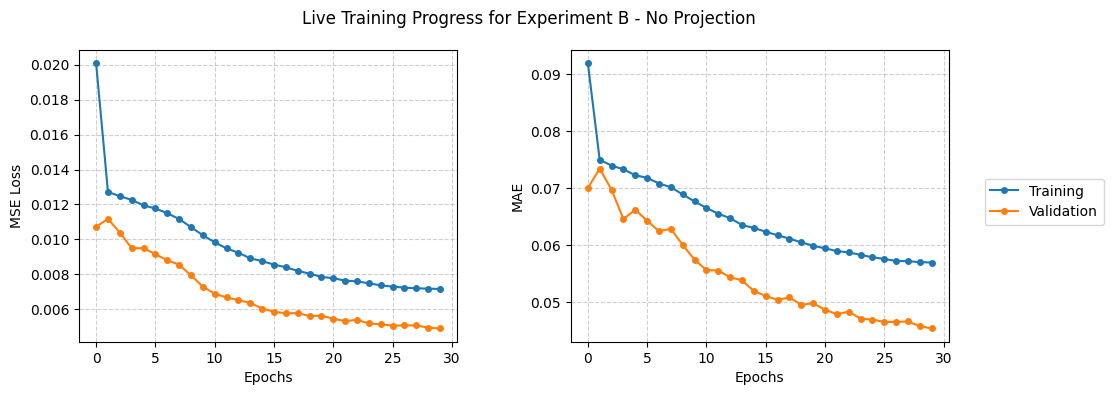

`Trainer.fit` stopped: `max_epochs=30` reached.


Using 16bit Automatic Mixed Precision (AMP)



>>> Starting experiment run "Experiment B - Linear Projection"...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ torch_core_model │ DecoderOnlyModule │  191 K │ train │     0 │
│ 1 │ mse              │ ModuleDict        │      0 │ train │     0 │
│ 2 │ mae              │ ModuleDict        │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

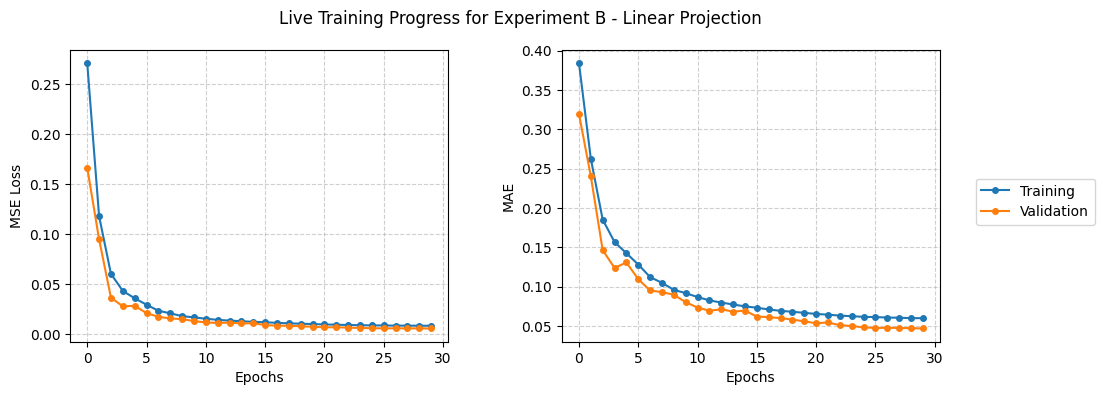

`Trainer.fit` stopped: `max_epochs=30` reached.


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores



>>> Starting experiment run "Experiment B - Enhanced Feature Space"...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ torch_core_model │ DecoderOnlyModule │  2.4 M │ train │     0 │
│ 1 │ mse              │ ModuleDict        │      0 │ train │     0 │
│ 2 │ mae              │ ModuleDict        │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

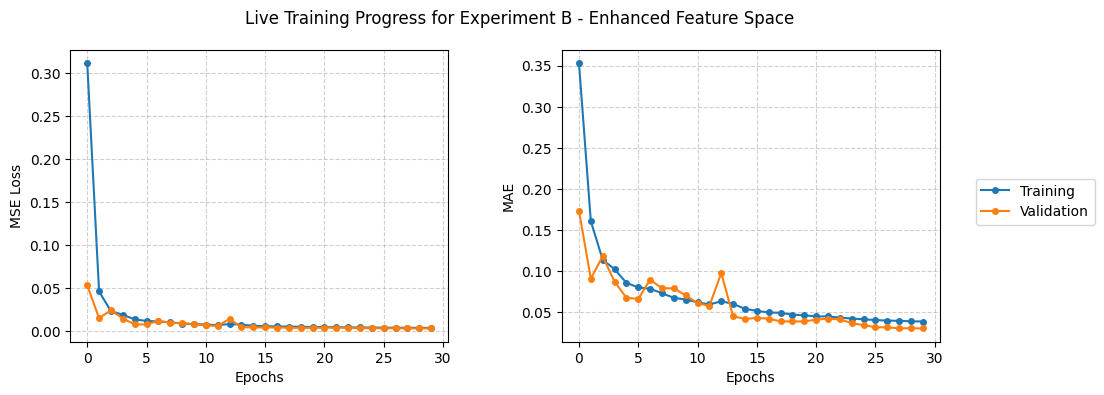

`Trainer.fit` stopped: `max_epochs=30` reached.


In [21]:
experiment_b_results = run_experiment(experiment_runs, shared_hparams)

## **Experiment C:** Single-Head vs. Multi-Head

### **C.1** Defining the **`LightningDataModule`**

In [23]:
# Covered by step ALL.1 above.

### **C.2** Defining a general **`LightningModule`**

In [24]:
# Covered by step ALL.2 above.

### **C.3** Define the experiment

In [ ]:
shared_hparams = {
    **general_hparams,
    # >>> BEGIN: Use the most promising results from experiment B.
    'use_feature_projection': True,
    'model_dim': 128,
    # <<< END: Use the most promising results from experiment B.
    'context_window_size': 24,
    'prediction_mode': 'many-to-one',
    'output_mode': 'point'
}

experiment_runs = [
    # The single-head attention experiment run has already been conducted above in experiment B.
    # {
    #     'name': 'Experiment C - Single-Head Attention',           # see 'Experiment B - Enhanced Feature Space'
    #     'num_heads': 1
    # },
    {
        'name': 'Experiment C - Multi-Head Attention with 4 Heads',
        'num_heads': 4
    },
    {
        'name': 'Experiment C - Multi-Head Attention with 8 Heads',
        'num_heads': 8
    },
    {
        'name': 'Experiment C - Multi-Head Attention with 16 Heads',
        'num_heads': 16
    }
]

### **C.4** Running the experiment

In [ ]:
experiment_c_results = run_experiment(experiment_runs, shared_hparams)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores



>>> Starting experiment "Experiment C - Multi-Head Attention with 4 Heads"...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ torch_core_model │ DecoderOnlyModule │  2.4 M │ train │     0 │
│ 1 │ mse              │ ModuleDict        │      0 │ train │     0 │
│ 2 │ mae              │ ModuleDict        │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


## **Experiment D:** Temporal Context Length

### **D.1** Defining the **`LightningDataModule`**

In [28]:
# Covered by step ALL.1 above.

### **D.2** Defining a general **`LightningModule`**

In [29]:
# Covered by step ALL.2 above.

### **D.3** Defining the experiment

In [ ]:
shared_hparams = {
    **general_hparams,
    # >>> BEGIN: Use the most promising results from experiment B.
    'use_feature_projection': True,
    'model_dim': 128,
    # <<< END: Use the most promising results from experiment B.
    # >>> BEGIN: Use the most promising results from experiment C.
    'num_heads': 8,
    # <<< END: Use the most promising results from experiment C.
    'prediction_mode': 'many-to-one',
    'output_mode': 'point'
}

experiment_runs = [
    # The 24-hour context window experiment run has already been conducted above in experiment C.
    # {
    #     'name': 'Experiment D - 24-Hour Context Window',          # see 'Experiment C - Multi-Head Attention with 8 Heads'
    #     'context_window_size': 24
    # },
    {
        'name': 'Experiment D - 72-Hour Context Window',
        'context_window_size': 72
    },
    {
        'name': 'Experiment D - 168-Hour Context Window',
        'context_window_size': 168
    },
    {
        'name': 'Experiment D - 720-Hour Context Window',
        'context_window_size': 720,
        'batch_size': 128                                           # deliberately reduce the batch size to avoid out-of-memory errors due to the O(L²) nature of self-attention, where L: context-window length.
    }
]

### **D.4** Running the experiment

In [ ]:
experiment_d_results = run_experiment(experiment_runs, shared_hparams)


>>> Starting experiment "Experiment D - 72-Hour Context Window"...


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ torch_core_model │ DecoderOnlyModule │  2.4 M │ train │     0 │
│ 1 │ mse              │ ModuleDict        │      0 │ train │     0 │
│ 2 │ mae              │ ModuleDict        │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


## **Experiment E:** Sequence-to-One vs. Sequence-to-Sequence

### **E.1** Defining the **`LightningDataModule`**

In [ ]:
# Covered by step ALL.1 above.

### **E.2** Defining a general **`LightningModule`**

In [ ]:
# Covered by step ALL.2 above.

### **E.3** Defining the experiment

In [ ]:
shared_hparams = {
    **general_hparams,
    # >>> BEGIN: Use the most promising results from experiment B.
    'use_feature_projection': True,
    'model_dim': 128,
    # <<< END: Use the most promising results from experiment B.
    # >>> BEGIN: Use the most promising results from experiment C.
    'num_heads': 8,
    # <<< END: Use the most promising results from experiment C.
    # >>> BEGIN: Use the most promising result from experiment D.
    'context_window_size': 168,
    # <<< END: Use the most promising result from experiment D.
    'output_mode': 'point'
}

experiment_runs = [
    # The sequence-to-one experiment run has already been conducted above in experiment D.
    # {
    #     'name': 'Experiment E - Sequence-to-One',                 # see 'Experiment D - 168-Hour Context Window'
    #     'prediction_mode': 'many-to-one'
    # },
    {
        'name': 'Experiment E - Sequence-to-Sequence',
        'prediction_mode': 'many-to-many'
    },
]

### **E.4** Running the experiment

In [ ]:
experiment_e_results = run_experiment(experiment_runs, shared_hparams)

## **Experiment F:** Point Forecasting (single value) vs. Probabilistic Forecasting (distribution)

### **F.1** Defining the **`LightningDataModule`**

In [44]:
# Covered by step ALL.1 above.

### **F.2** Defining a general **`LightningModule`**

In [45]:
# Covered by step ALL.2 above.

### **F.3** Defining the experiment

In [ ]:
shared_hparams = {
    **general_hparams,
    # >>> BEGIN: Use the most promising results from experiment B.
    'use_feature_projection': True,
    'model_dim': 128,
    # <<< END: Use the most promising results from experiment B.
    # >>> BEGIN: Use the most promising results from experiment C.
    'num_heads': 8,
    # <<< END: Use the most promising results from experiment C.
    # >>> BEGIN: Use the most promising result from experiment D.
    'context_window_size': 168,
    # <<< END: Use the most promising result from experiment D.
    # >>> BEGIN: Use the most promising result from experiment E.
    'prediction_mode': 'many-to-many',
    # <<< END: Use the most promising result from experiment E.
}

experiment_runs = [
    # The point-based output experiment run has already been conducted above in experiment E.
    # {
    #     'name': 'Experiment F - Point-based Output',              # see 'Experiment E - Sequence-to-Sequence'
    #     'output_mode': 'point'
    # },
    {
        'name': 'Experiment F - Distribution-based Output',
        'output_mode': 'distribution'
    },
]

### **F.4** Running the experiment

In [ ]:
experiment_f_results = run_experiment(experiment_runs, shared_hparams)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores



>>> Starting experiment "Experiment F - Distribution-based Output"...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ torch_core_model │ DecoderOnlyModule │  2.4 M │ train │     0 │
│ 1 │ mse              │ ModuleDict        │      0 │ train │     0 │
│ 2 │ mae              │ ModuleDict        │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


# **Tensorboard**

In [1]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [2]:
# Make sure, that `LOG_PATH` exists.
try:
    LOG_PATH
except NameError:
    LOG_PATH = './logs/'

In [4]:
# Opens tensorboard in notebook using the specified log directory.
%tensorboard --logdir '{LOG_PATH}'

Reusing TensorBoard on port 6006 (pid 36896), started 0:00:05 ago. (Use '!kill 36896' to kill it.)